## Неделя 3. Среда
### Временные ряды

В этом задании тебе предстоит проанализировать продажи разных категорий товаров. Сначала это стоит сделать для одной категории, потом можно попробовать для других. 

1. Загрузи [датасет](https://community.tableau.com/s/question/0D54T00000CWeX8SAL/sample-superstore-sales-excelxls) и распечатай первые 10 строк. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.style.use('seaborn-v0_8')

In [3]:
df = pd.read_excel('Sample - Superstore.xls')
df = df[df['Category'] == 'Furniture']

Сделай выбоорку по категории товара (используй популярную категорию: например, `Furniture`) и запиши в переменную `data`. Распечатай первые 10 строк. 

In [4]:
data = df[df["Category"] == "Furniture"]
data.head(10)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
5,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
10,11,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092
23,24,US-2017-156909,2017-07-16,2017-07-18,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,...,19140,East,FUR-CH-10002774,Furniture,Chairs,"Global Deluxe Stacking Chair, Gray",71.3720,2,0.30,-1.0196
24,25,CA-2015-106320,2015-09-25,2015-09-30,Standard Class,EB-13870,Emily Burns,Consumer,United States,Orem,...,84057,West,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1044.6300,3,0.00,240.2649
27,28,US-2015-150630,2015-09-17,2015-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7,0.50,-1665.0522
29,30,US-2015-150630,2015-09-17,2015-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,FUR-FU-10004848,Furniture,Furnishings,"Howard Miller 13-3/4"" Diameter Brushed Chrome ...",124.2000,3,0.20,15.5250
36,37,CA-2016-117590,2016-12-08,2016-12-10,First Class,GH-14485,Gene Hale,Corporate,United States,Richardson,...,75080,Central,FUR-FU-10003664,Furniture,Furnishings,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",190.9200,5,0.60,-147.9630


2. Визуализируй данные:
    * по исходному целевому столбцу (`Sales`)
    * усреднить просуммировать по разным периодам (неделя, месяц, квартал, полугодие)

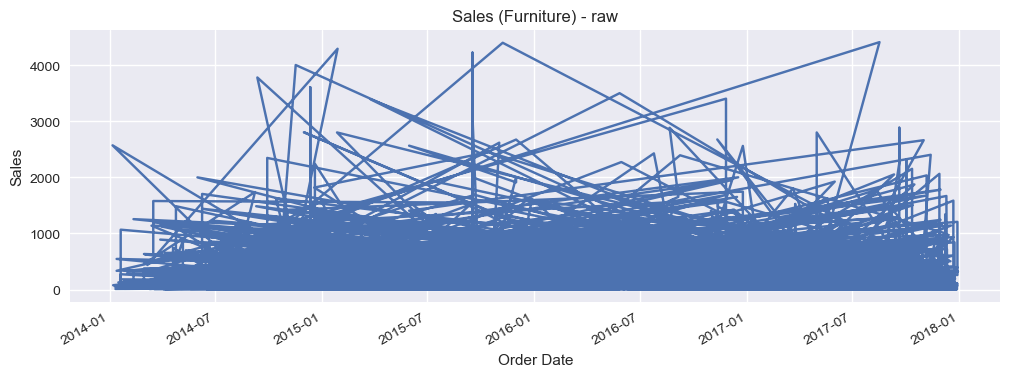

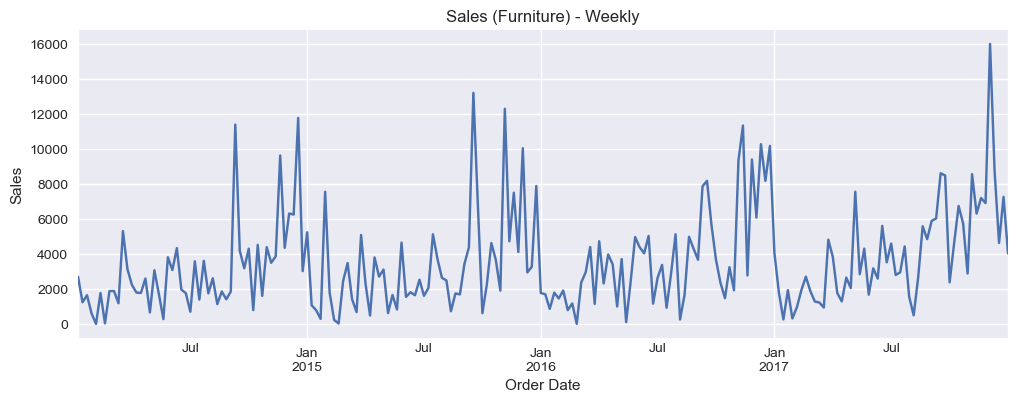

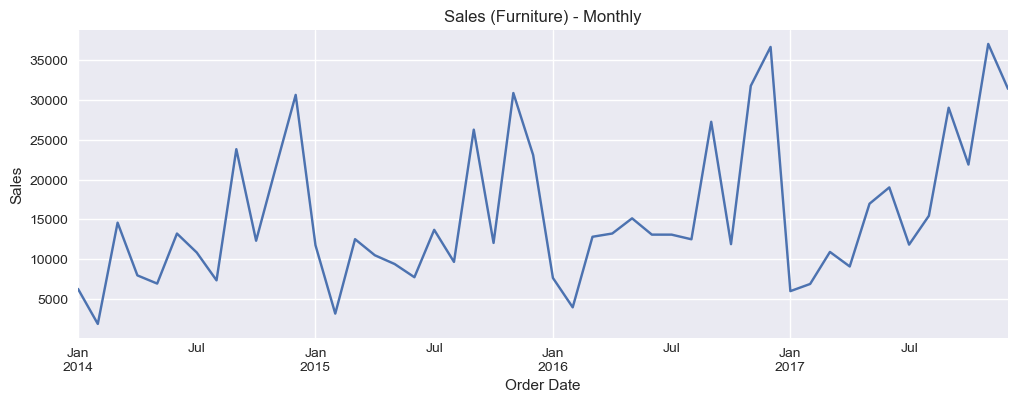

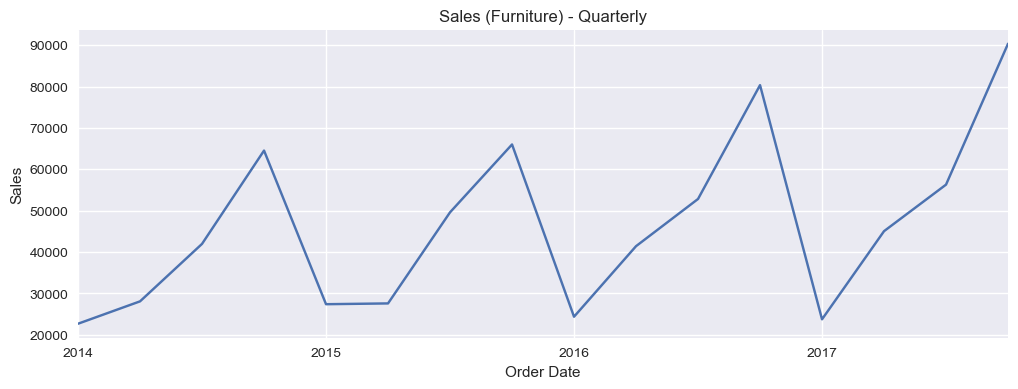

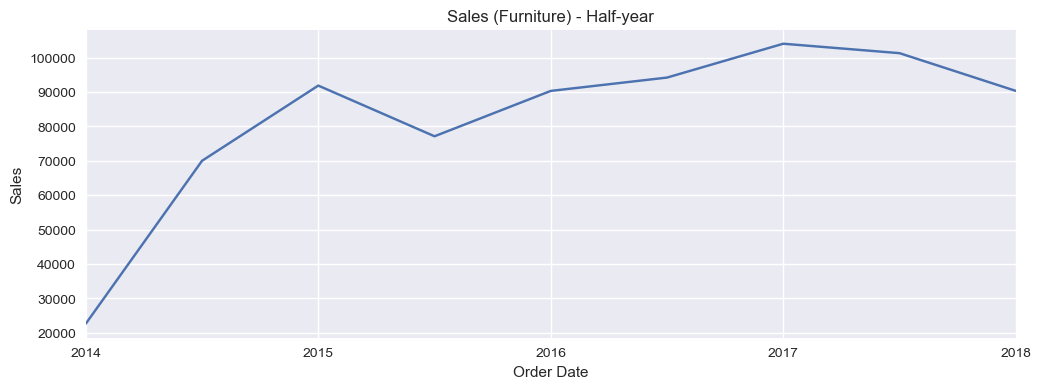

In [5]:
data["Order Date"] = pd.to_datetime(data["Order Date"])

data_ts = data.set_index("Order Date")["Sales"]

# ---- 1. Визуализация исходных продаж ----
plt.figure(figsize=(12,4))
data_ts.plot(title="Sales (Furniture) - raw")
plt.ylabel("Sales")
plt.show()

# ---- 2. Агрегации ----
periods = {
    "W": "Weekly",      
    "M": "Monthly",  
    "Q": "Quarterly",   
    "2Q": "Half-year"  
}

for rule, label in periods.items():
    agg = data_ts.resample(rule).sum()
    plt.figure(figsize=(12,4))
    agg.plot(title=f"Sales (Furniture) - {label}")
    plt.ylabel("Sales")
    plt.show()


2.1 В качестве анализа необходимо взять временной ряд по __неделям__, и анализировать __сумму__. 

In [6]:

weekly_sales = data_ts.resample("W").sum()

weekly_sales.head()




Order Date
2014-01-12    2712.428
2014-01-19    1250.473
2014-01-26    1655.958
2014-02-02     623.666
2014-02-09      14.560
Freq: W-SUN, Name: Sales, dtype: float64

In [14]:
weekly_sales.to_csv('test.csv')

3. Построй визуализации:
* скользящего среднего


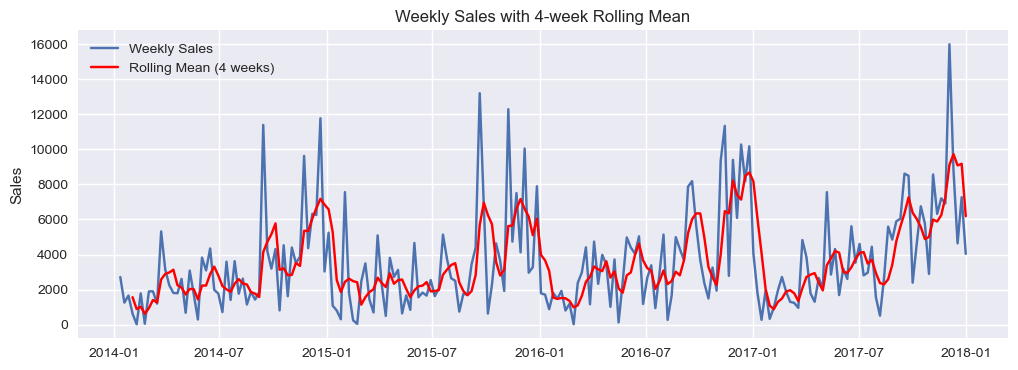

In [7]:
rolling_4w = weekly_sales.rolling(window=4).mean()

plt.figure(figsize=(12,4))
plt.plot(weekly_sales, label="Weekly Sales")
plt.plot(rolling_4w, label="Rolling Mean (4 weeks)", color="red")
plt.title("Weekly Sales with 4-week Rolling Mean")
plt.ylabel("Sales")
plt.legend()
plt.show()



* взвешенного скользящего среднего


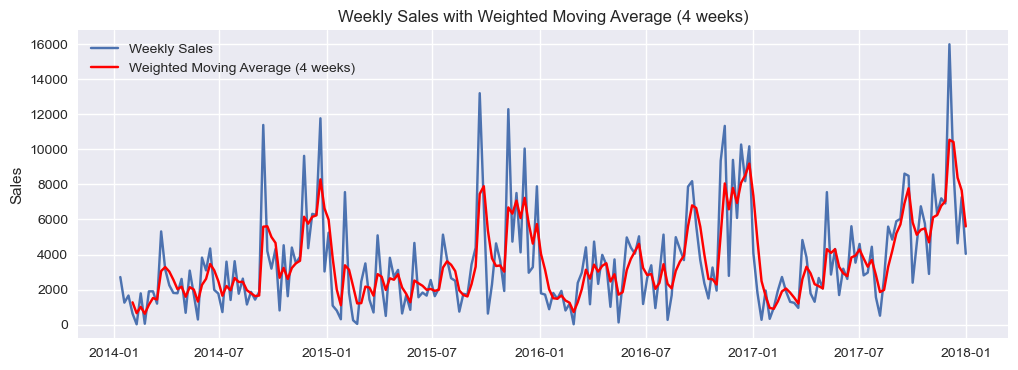

In [8]:
window = 4
weights = np.arange(1, window + 1)

# взвешенное скользящее среднее
wma = weekly_sales.rolling(window).apply(
    lambda x: np.dot(x, weights) / weights.sum(), raw=True
)

plt.figure(figsize=(12, 4))
plt.plot(weekly_sales, label="Weekly Sales")
plt.plot(wma, label="Weighted Moving Average (4 weeks)", color="red")
plt.title("Weekly Sales with Weighted Moving Average (4 weeks)")
plt.ylabel("Sales")
plt.legend()
plt.show()

Какие выводы можно сделать по скользящим линиям? Что они показывают?

4. Декомпозируй данные на тренд, сезонность и остатки. 

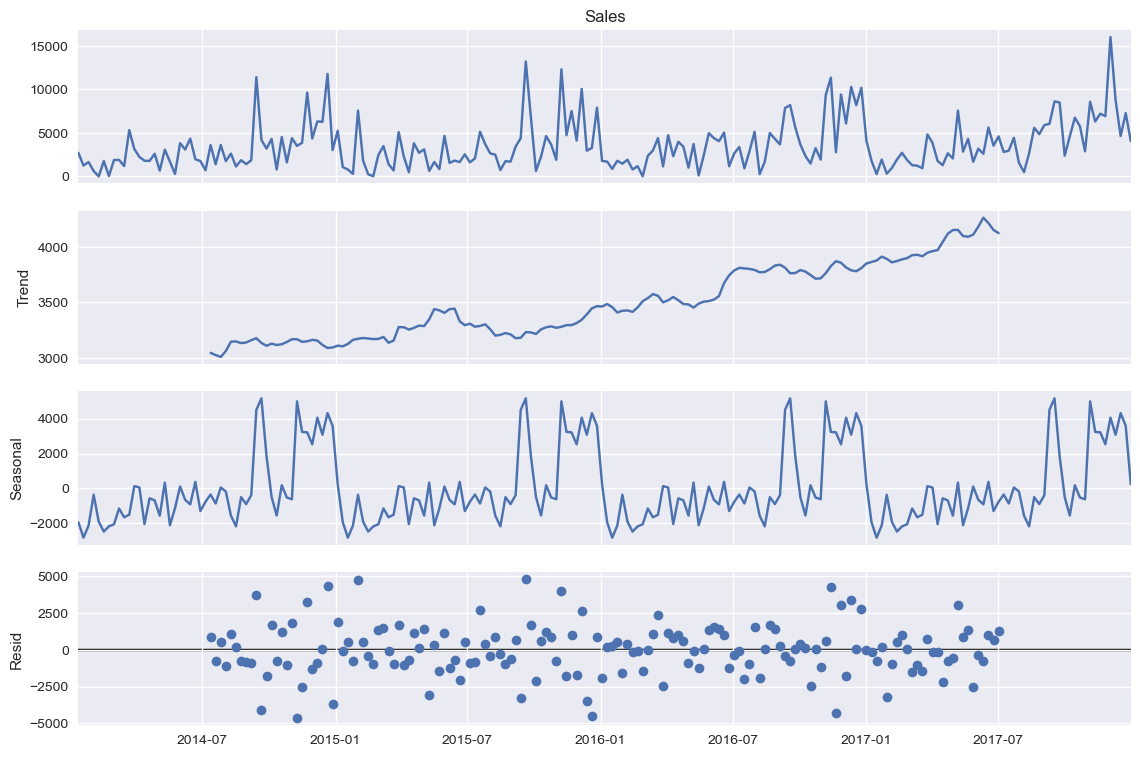

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Декомпозиция с сезонностью по году (52 недели)
decomp = seasonal_decompose(weekly_sales, model="additive", period=52)

# Строим графики
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.show()


# ❓
Прокомментируй графики: какой вывод можно сделать? Есть ли в данных сезонность? Какой тренд преобладает? Какого масштаба ошибки по сравнению со значениями основного временного ряда?

> ответ тут

Тренд восходящий, сезонность выраженная

5. Построй графики автокорреляционной функции и частичной автокорреляционной функции. 

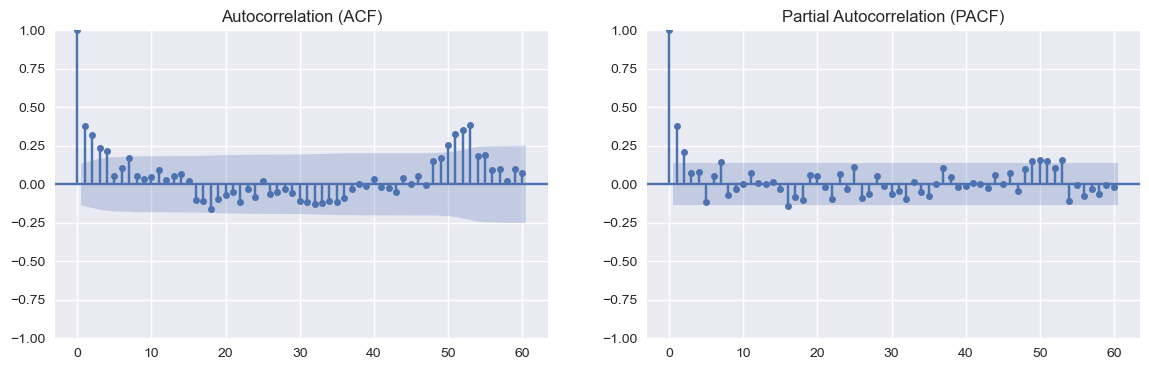

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

y = weekly_sales

fig, axes = plt.subplots(1, 2, figsize=(14,4))

# Автокорреляционная функция (ACF)
plot_acf(y, lags=60, ax=axes[0])
axes[0].set_title("Autocorrelation (ACF)")

# Частичная автокорреляционная функция (PACF)
plot_pacf(y, lags=60, ax=axes[1])
axes[1].set_title("Partial Autocorrelation (PACF)")

plt.show()


# ❓
Какие выводы можно сделать на основе этих графиков?

> ответ тут

Автокорреляция короткая. Значимы только первые 3 лага

6. Постройте и визуализируйте модель класса ARIMA

AIC: 3609.75 | Test MAE: 3536 | RMSE: 4649


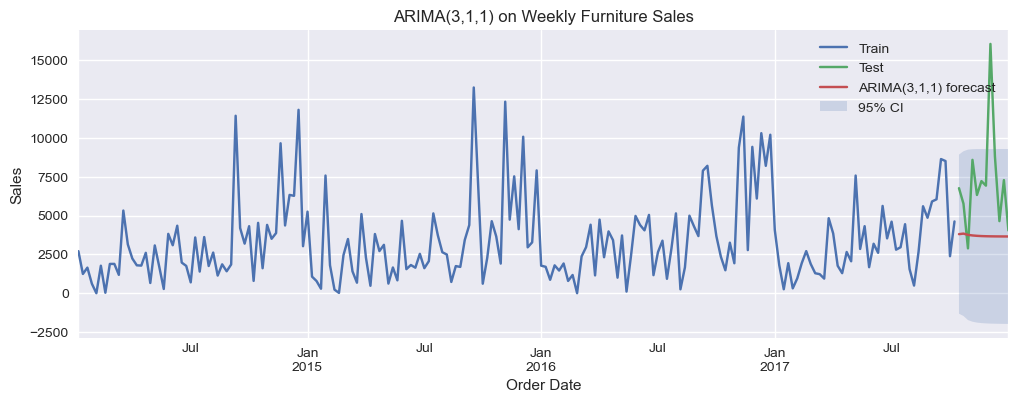

In [11]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Трейн/тест сплит
h = 12 if len(weekly_sales) > 60 else max(6, len(weekly_sales)//10)
y_train, y_test = weekly_sales.iloc[:-h], weekly_sales.iloc[-h:]

# Обучение ARIMA(p,d,q)
model = ARIMA(y_train, order=(3, 1, 1))  
fit = model.fit()

# Прогноз на тестовый горизонт + доверительный интервал
fc = fit.get_forecast(steps=h)
y_pred = pd.Series(fc.predicted_mean, index=y_test.index)
ci = fc.conf_int()                      # 2 колонки: lower/upper
lower = pd.Series(ci.iloc[:, 0].astype(float).values, index=y_test.index)
upper = pd.Series(ci.iloc[:, 1].astype(float).values, index=y_test.index)

# Метрики
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"AIC: {fit.aic:.2f} | Test MAE: {mae:.0f} | RMSE: {rmse:.0f}")

# Визуализация
plt.figure(figsize=(12,4))
y_train.plot(label="Train")
y_test.plot(label="Test")
y_pred.plot(label="ARIMA(3,1,1) forecast")
plt.fill_between(y_test.index, lower.values, upper.values, alpha=0.2, label="95% CI")
plt.title("ARIMA(3,1,1) on Weekly Furniture Sales")
plt.ylabel("Sales")
plt.legend()
plt.show()


c:\Users\user\miniforge3\envs\eda_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


AIC: 2658.9 | MAE: 1860 | RMSE: 2658


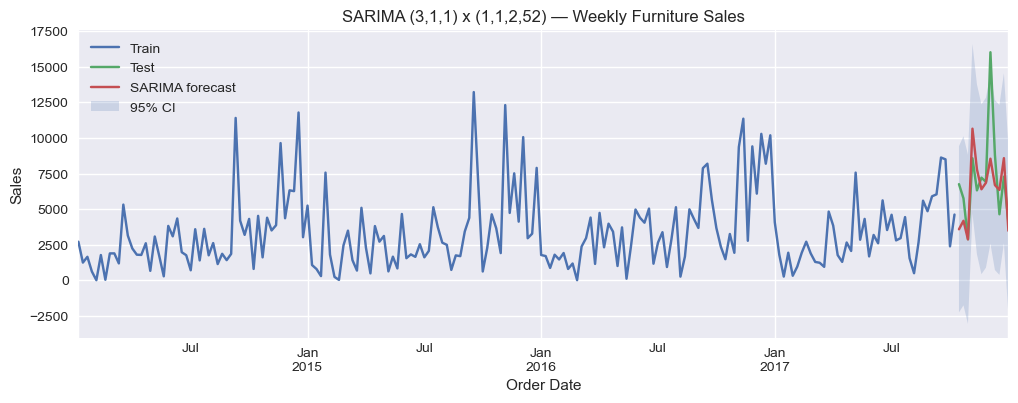

In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

y = data.set_index("Order Date")["Sales"].resample("W").sum()

# Трейн/тест
h = 12 
y_train, y_test = y.iloc[:-h], y.iloc[-h:]

# SARIMAX: (p,d,q) и сезонные (P,D,Q,s) с годовой сезонностью по неделям s=52
model = SARIMAX(
    y_train,
    order=(3,1,1),            
    seasonal_order=(1,1,2,52),  
    trend='c'                 
)
fit = model.fit(disp=False)

# Прогноз и доверительные интервалы
fc = fit.get_forecast(steps=h)
y_pred = pd.Series(fc.predicted_mean, index=y_test.index)
ci = fc.conf_int()
lower = pd.Series(ci.iloc[:,0].astype(float).values, index=y_test.index)
upper = pd.Series(ci.iloc[:,1].astype(float).values, index=y_test.index)

# Метрики
mae  = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"AIC: {fit.aic:.1f} | MAE: {mae:.0f} | RMSE: {rmse:.0f}")

# Визуализация
plt.figure(figsize=(12,4))
y_train.plot(label="Train")
y_test.plot(label="Test")
y_pred.plot(label="SARIMA forecast")
plt.fill_between(y_test.index, lower.values, upper.values, alpha=0.2, label="95% CI")
plt.title("SARIMA (3,1,1) x (1,1,2,52) — Weekly Furniture Sales")
plt.ylabel("Sales")
plt.legend(); plt.show()


7. Постройте и визуализируйте модель prophet. Попробуйте подобрать оптимальные параметры

In [13]:
from prophet import Prophet

h = 12  
# Подготовка под Prophet (ds, y)
full = weekly_sales.rename("y").to_frame()
full["ds"] = full.index
full = full[["ds", "y"]]

train = full.iloc[:-h].copy()
test  = full.iloc[-h:].copy()

# Модель Prophet
m = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.5,   # гибкость тренда
    seasonality_mode="additive"    # 'additive' или 'multiplicative'
)
m.add_seasonality(name="yearly", period=365.25, fourier_order=10, prior_scale=10.0)

m.fit(train)

# Прогноз на h недель вперёд
future = m.make_future_dataframe(periods=h, freq="W")
fcst = m.predict(future)

# Оценка на тесте
y_pred = fcst.set_index("ds").loc[test["ds"], "yhat"]
mae  = mean_absolute_error(test["y"], y_pred)
rmse = root_mean_squared_error(test["y"], y_pred)
print(f"MAE: {mae:.0f} | RMSE: {rmse:.0f}")

# Визуализация прогноза
plt.figure(figsize=(12,4))
plt.plot(train["ds"], train["y"], label="Train")
plt.plot(test["ds"],  test["y"],  label="Test")
plt.plot(y_pred.index, y_pred.values, label="Prophet forecast")
plt.title("Prophet — Weekly Furniture Sales")
plt.ylabel("Sales"); plt.legend(); plt.show()

# Компоненты (тренд/сезонность)
m.plot_components(fcst); plt.show()


ModuleNotFoundError: No module named 'prophet'

8. Примени регрессионные модели (случайный лес или градиентный бустинг) для прогнозирования целевой величины.
   * Пример есть в демо

In [ ]:
# code

9. Создайте Streamlit-приложение, в которое пользователь сможет загрузить свой файл с временным рядом, и получить результат предсказания, а так же метрики и интерпретацию результатов

10*. Если останется время, можно попробовать дополнительно одну из библиотек: 
* [Darts](https://habr.com/ru/articles/659405/)
* [Merlion](https://habr.com/ru/companies/sportmaster_lab/articles/792318/)
* [tsfresh](https://tsfresh.readthedocs.io/en/latest/)
* [Kats](https://github.com/facebookresearch/Kats)
* [autots](https://winedarksea.github.io/AutoTS/build/html/source/tutorial.html)

In [ ]:
# code

<img src="https://icons.iconarchive.com/icons/icons8/windows-8/256/Programming-Github-icon.png" width=32 /> Сохрани файл для __github__. 
